In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [4]:
# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/shreyasdasari7/top-100-saas-companiesstartups/top_100_saas_companies_2025.csv")
print(df.shape)
print(df.info())
print('--- First 5 Companies ---')
print(df.head(5))

(100, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company Name   100 non-null    object 
 1   Founded Year   100 non-null    int64  
 2   HQ             100 non-null    object 
 3   Industry       100 non-null    object 
 4   Total Funding  99 non-null     object 
 5   ARR            100 non-null    object 
 6   Valuation      100 non-null    object 
 7   Employees      100 non-null    object 
 8   Top Investors  100 non-null    object 
 9   Product        100 non-null    object 
 10  G2 Rating      100 non-null    float64
dtypes: float64(1), int64(1), object(9)
memory usage: 8.7+ KB
None
--- First 5 Companies ---
  Company Name  Founded Year                      HQ               Industry  \
0    Microsoft          1975        Redmond, WA, USA    Enterprise Software   
1   Salesforce          1999  San Francisco, CA, USA           

In [10]:
def clean_currency(value):
    if pd.isna(value) or value == 'NaN':
        return np.nan
    
    # 1. Use Regex to find the first number + suffix (e.g., 27.7B) 
    # and ignore anything in parentheses
    match = re.search(r'([\d\.]+)\s*([TBMK]?)', str(value))
    
    if not match:
        return np.nan
    
    number = float(match.group(1))
    suffix = match.group(2)

    # 2. Apply the conversion logic
    if suffix == 'T':
        return number * 1000  # Trillion to Billion
    elif suffix == 'B' or suffix == '':
        return number
    elif suffix == 'M':
        return number / 1000  # Million to Billion
    elif suffix == 'K':
        return number / 1000000 # Thousand to Billion
        
    return number

In [11]:
# Apply the function
df['ARR_B'] = df['ARR'].apply(clean_currency)
df['Valuation_B'] = df['Valuation'].apply(clean_currency)

# Cleaning Employees by removing ','
df['Employees'] = df['Employees'].astype(str).str.replace(',', '').str.replace('+', '').astype(float)

# Verify
print(df[['Company Name', 'ARR_B', 'Valuation_B', 'Employees']].head())

  Company Name  ARR_B  Valuation_B  Employees
0    Microsoft  270.0       3000.0   221000.0
1   Salesforce   37.9        227.8    75000.0
2        Adobe   19.4        240.0    29945.0
3       Oracle   52.9        350.0   143000.0
4          SAP   32.5        215.0   107415.0


In [14]:
# Calculate Valuation-to-ARR 
df['Revenue_Multiple'] = df['Valuation_B'] / df['ARR_B']

# Sort by Valuation 
top_10_giants = df.sort_values(by='Valuation_B', ascending=False).head(10)

print('--- Top 10 Saas Giants by Valuation ---')
print(top_10_giants[['Company Name', 'Valuation_B', 'ARR_B', 'Revenue_Multiple']])

--- Top 10 Saas Giants by Valuation ---
          Company Name  Valuation_B  ARR_B  Revenue_Multiple
0            Microsoft       3000.0  270.0         11.111111
3               Oracle        350.0   52.9          6.616257
2                Adobe        240.0   19.4         12.371134
1           Salesforce        227.8   37.9          6.010554
4                  SAP        215.0   32.5          6.615385
5               Intuit        180.0   14.4         12.500000
6           ServiceNow        147.0    8.9         16.516854
9              Shopify         95.0    7.1         13.380282
57  Palo Alto Networks         95.0    7.5         12.666667
8                 Zoom         85.0    4.5         18.888889


In [15]:
# Grouping by Industry to see total Valuation and Average G2 Rating
industry_analysis = df.groupby('Industry').agg({
    'Valuation_B': 'sum',
    'ARR_B': 'sum',
    'G2 Rating': 'mean',
    'Company Name': 'count'
}).rename(columns={'Company Name': 'Company_Count'}).reset_index()

# Calculate Industry-wide Multiple
industry_analysis['Industry_Multiple'] = industry_analysis['Valuation_B'] / industry_analysis['ARR_B']

# Display the top 5 industries by total valuation
print('--- Industry Performance Summary ---')
print(industry_analysis.sort_values(by='Valuation_B', ascending=False).head(5))

--- Industry Performance Summary ---
                 Industry  Valuation_B  ARR_B  G2 Rating  Company_Count  \
36    Enterprise Software       3215.0  302.5       4.25              2   
26  Database & Enterprise        350.0   52.9       4.00              1   
14      Creative Software        240.0   19.4       4.50              1   
4                     CRM        227.8   37.9       4.30              1   
44     Financial Software        180.0   14.4       4.40              1   

    Industry_Multiple  
36          10.628099  
26           6.616257  
14          12.371134  
4            6.010554  
44          12.500000  


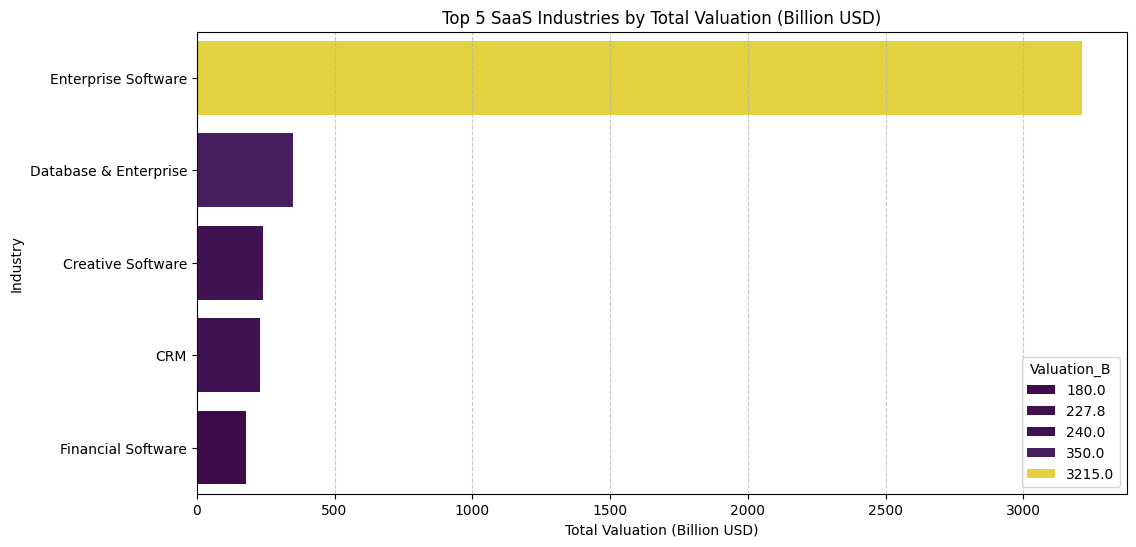

In [18]:
# Sorting for the plot
top_industries = industry_analysis.sort_values(by='Valuation_B', ascending=False).head(5)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_industries, x='Valuation_B', y='Industry',hue='Valuation_B', palette='viridis')

plt.title('Top 5 SaaS Industries by Total Valuation (Billion USD)')
plt.xlabel('Total Valuation (Billion USD)')
plt.ylabel('Industry')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [21]:
# Calculate Valuation per Employee (in Millions USD per person)
# We multiply by 1000 because Valuation_B is in Billions.
df['Val_per_Emp_M'] = (df['Valuation_B'] * 1000) / df['Employees']

# Show the top 5 most "Lean" companies
print("--- Top 5 Most Efficient Companies (Valuation per Employee) ---")
print(df.sort_values(by='Val_per_Emp_M', ascending=False)[['Company Name', 'Val_per_Emp_M', 'Employees']].head(5))

--- Top 5 Most Efficient Companies (Valuation per Employee) ---
   Company Name  Val_per_Emp_M  Employees
46    Grammarly      21.666667      600.0
76        Plaid      16.750000      800.0
79         Ramp      16.200000      500.0
27        Figma      15.384615     1300.0
22     Palantir      14.857143     3500.0


📊 Key Insights for Kaggle
--------------------------
-   **Valuation vs. Efficiency:** While **Microsoft** leads in absolute Valuation (**3,000 Billion USD**), **Zoom** dominates in market sentiment with a **18.89x Revenue Multiple**, signaling that investors prioritize growth potential over current size.

-   **The "Lean" SaaS Model:** Efficiency varies wildly across the top 100. **Grammarly** leads the pack in human capital efficiency, boasting a valuation of **21.67 Million USD per employee**, proving that high-automation products scale better than service-heavy ones.

-   **Industry Powerhouses:** **Enterprise Software** remains the most valuable sector globally, but **Creative** and **Financial Software** sectors command the highest average valuation multiples (**~12.4x**), making them the most "expensive" industries to enter.

-   **Quality is Table Stakes:** There is a moderate positive correlation between **G2 Ratings** and **Valuation Multiples**, suggesting that while "good software" is expected, market dominance requires more than just high user ratings.